# `CRO` reproduces the ENSO characteristics in observations

This tutorial demonstrates how to use `pyCRO` to calibrate the Recharge Oscillator (RO) model against observed ENSO variability and evaluate how well the fitted stochastic RO model reproduces key characteristics of the observed ENSO system.

Starting from observed Niño3.4 SST anomalies and Warm Water Volume (WWV), we will

- fit the stochastic Recharge Oscillator parameters,
- generate stochastic large ensemble simulations,
- compare the simulated and observed ENSO statistics, and
- evaluate whether the model reproduces important dynamical characteristics such as seasonal synchronization, nonlinear asymmetry, persistence, phase relationships, and spectral peaks.

Although the Recharge Oscillator is a highly idealized model, this example illustrates that it captures many of the essential features of observed ENSO.

---

Contacts: Sen Zhao <zhaos@hawaii.edu>, Soong-Ki Kim <soong-ki.kim@yale.edu>



In [1]:
%config IPCompleter.greedy = True
%matplotlib inline
%config InlineBackend.figure_format='retina'

%load_ext autoreload
%autoreload 2

import os
import sys
    
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

## comment this if you install pyCRO already
sys.path.append(os.path.abspath("../../../"))

import pyCRO

## Load XRO for using some stats and plot functions
import XRO

## Load Observed Nino3.4 and WWV time series

We begin by loading monthly observations of

- **Niño3.4 SST anomaly**, representing the eastern-central tropical Pacific sea surface temperature anomalies that define ENSO, and
- **Warm Water Volume (WWV)**, representing the equatorial Pacific upper-ocean heat content, which provides the "memory" of the ENSO system.

The observations are taken from the ORAS5 ocean reanalysis. These two variables form the state variables of the Recharge Oscillator model.


Text(0.5, 1.0, 'WWV anomaly')

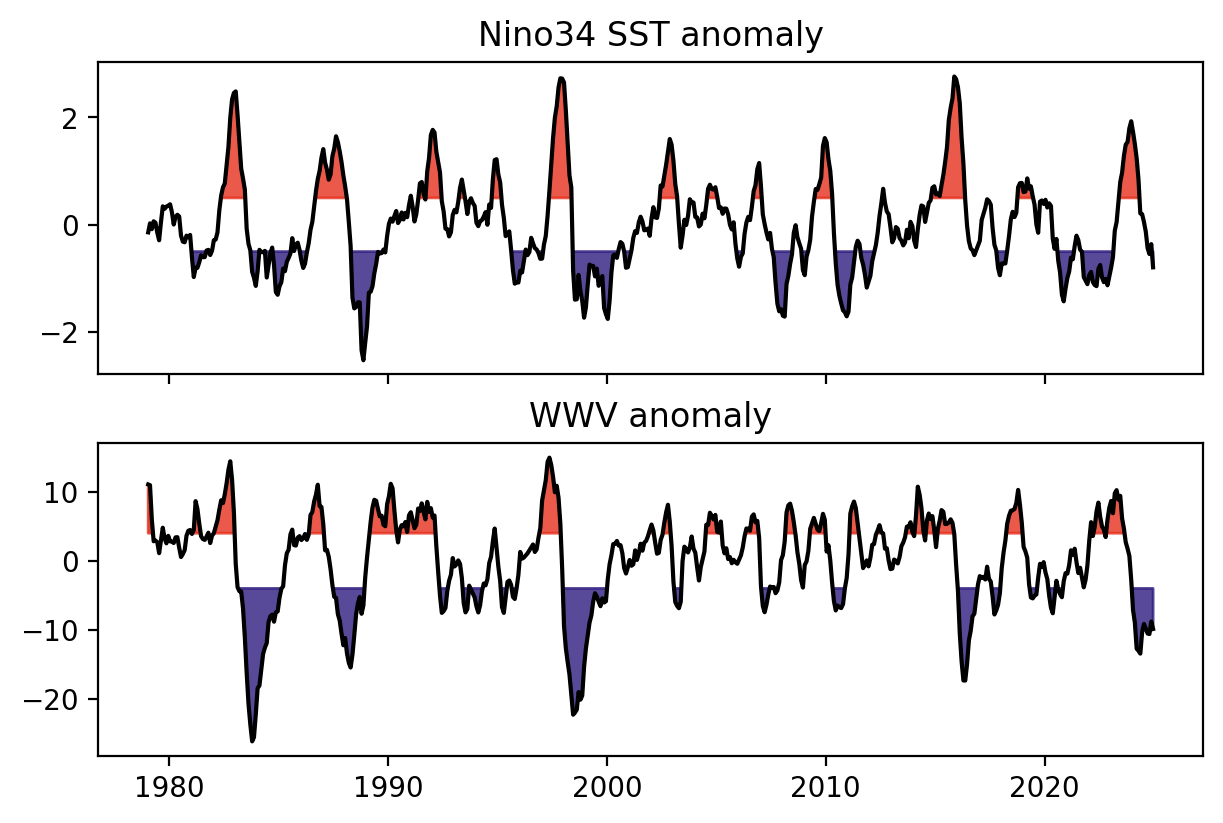

In [2]:
# load observations
file_name = os.path.join(os.getcwd(), "../../../data", "XRO_indices_oras5.nc")
obs_ds = xr.open_dataset(file_name)
T_oras5 = obs_ds['Nino34'][:]  # Nino 3.4 since 1979-01-01
h_oras5 = obs_ds['WWV'][:]     # WWV since 1979-01-01
time_oras5 = obs_ds['time'][:] # Days since 1979-01-01

fig, axes = plt.subplots(2, 1, figsize=(6, 4), sharex=True, layout='compressed')

XRO.plot_above_below_shading(T_oras5, ax=axes[0])
axes[0].set_title("Nino34 SST anomaly")
XRO.plot_above_below_shading(h_oras5, above=4, below=-4, ax=axes[1])
axes[1].set_title("WWV anomaly")

##  Fit the observed Recharge Oscillator using `pyCRO`

The Recharge Oscillator contains a small number of physically interpretable parameters describing

- ENSO linear RO parameters (R and epsilon, F1 and F2)
- Sonlinear feedbacks (b_T, c_T, d_T and b_h)
- Stochastic noise (red or white, addtive or multiplicative)

check details at https://senclimate.github.io/CRO/python/notebooks/model_parameters.html

Here we estimate these parameters directly from the observed Niño3.4 and WWV time series using `pyCRO.RO_fitting()`.

The fitted parameter set will later be used to generate stochastic simulations of ENSO.

In [3]:
par_option_T = {"R": 3, "F1": 3, "b_T": 3, "c_T": 3, "d_T": 3}
par_option_h = {"F2": 3, "epsilon": 3, "b_h": 3}
par_option_noise = {"T": "red", "h": "red", "T_type": "additive"}

par_obs_fit = pyCRO.RO_fitting(T_oras5, h_oras5, par_option_T, par_option_h, par_option_noise)
par_obs_fit

---------------------------------------------------------------------------------
Welcome to CRO Fitting! Your fitting setups:
---------------------------------------------------------------------------------
 - Data time step is not given, defaulting to: dt = 1.0 months.
 - Time series length: N = len(T)*dt = 552.0 months.
 - Prescribed terms: {'R': 3, 'F1': 3, 'b_T': 3, 'c_T': 3, 'd_T': 3}. 
                     {'F2': 3, 'epsilon': 3, 'b_h': 3}. 
   0 - Do not prescribe. 
   1 - Prescribe only the annual mean. 
   3 - Prescribe the annual mean and annual seasonality. 
   5 - Prescribe the annual mean, annual seasonality, and semi-annual seasonality.
 - Noise options: {'T': 'red', 'h': 'red', 'T_type': 'additive'}.
 - Fitting method for T and h red noises: ARn.
   This option is defined internally within fit.py.
   Options available are: LR or AR1 or ARn.
 - Fitting method for T and h main equations: None.
Referring to table_default_fitting_method.txt and using LR-F
-----------------

{'R': [-0.03825662645116978, 0.15279261078709938, -2.6649612108850858],
 'F1': [0.014880562265427005, 0.009087329137276353, -1.0317328772337753],
 'F2': [1.0869104940931087, 0.8361386030166872, 0.9978616403641568],
 'epsilon': [0.02686761171394478, 0.03811643856137864, 0.3515145112713421],
 'b_T': [0.015496318351061458, 0.021729096076101104, 0.15331564425037922],
 'c_T': [0.011128872454926822, 0.0076102493370564525, -1.481635571893312],
 'd_T': [0.008366435862437566, 0.00407903423721351, -1.4009025036331542],
 'b_h': [0.07951113081904398, 0.06548708161774486, 2.7744417360145146],
 'sigma_T': [0.19385539074958086],
 'sigma_h': [1.4970166742429747],
 'B': [],
 'm_T': [1.7019681246492098],
 'm_h': [1.673375811872759],
 'n_T': [0],
 'n_h': [0],
 'n_g': [2]}

## RO stochastic simulations

Using the fitted parameters, we integrate the stochastic Recharge Oscillator forward in time.

To obtain robust climate statistics, we generate a 100-member ensemble, with each member spanning 200 years. The long ensemble allows internal variability to be sampled while preserving the observed dynamics estimated from the fitting procedure.

In [4]:
def CRO_simulate(par, IC=[0, 0], N=12*200, NE=100, verbose=False):
    """
        CRO simulation (solver) with defined parameters

            default: 100 member with 200 yrs each member
    """
    T_out, h_out, noise_out = pyCRO.RO_solver(par, IC=IC, N=N, NE=NE, verbose=verbose)

    xtime = xr.date_range('0001-01', periods=N, freq = 'MS', use_cftime=True)
    member = np.arange(0, NE, step=1)
    T_ds = xr.DataArray(T_out, dims=("time","member"), coords={'time': xtime, 'member': member})
    h_ds = xr.DataArray(h_out, dims=("time","member"), coords={'time': xtime, 'member': member})
    RO_ds = xr.Dataset({'Nino34': T_ds, 'WWV': h_ds})
    return RO_ds


RO_sim = CRO_simulate(par_obs_fit, IC=[0, 0], N=12*200, NE=100, verbose=False)
RO_sim

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 2400, member: 100)
Coordinates:
  * time     (time) object 19kB 0001-01-01 00:00:00 ... 0200-12-01 00:00:00
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
Data variables:
    Nino34   (time, member) float64 2MB 0.0 0.0 0.0 0.0 ... 0.1311 1.19 -0.5809
    WWV      (time, member) float64 2MB 0.0 0.0 0.0 0.0 ... -8.547 -7.114 -8.508

## Seasonal varying standard deviation

One hallmark of ENSO is **seasonal synchronization**: ENSO events tend to reach their maximum amplitude during boreal winter.

Here we compare the monthly standard deviation of Niño3.4 between observations and the stochastic simulations. A successful model should reproduce both the timing and magnitude of this seasonal modulation.


Text(0.5, 1.0, 'CRO simulates ENSO seasonal synchronization')

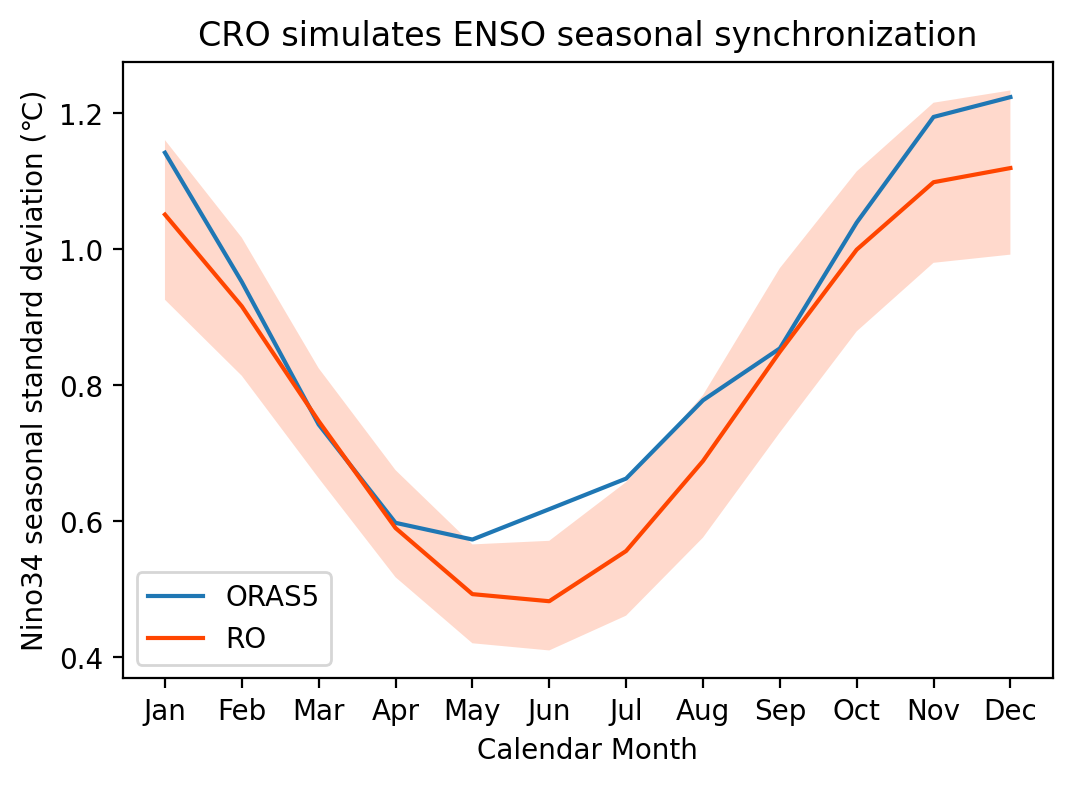

In [5]:
obs_seaSD = obs_ds.groupby('time.month').std('time')
RO_seaSD = RO_sim.groupby('time.month').std('time')

sel_var = "Nino34"
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
obs_seaSD[sel_var].plot(ax=ax, label='ORAS5')
XRO.plot_fill_between(RO_seaSD[sel_var], xtime=RO_seaSD.month, ax=ax, label='RO', option=0)

plt.legend()
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Nino34 seasonal standard deviation (℃)')
plt.xlabel('Calendar Month')
plt.title('CRO simulates ENSO seasonal synchronization')

## Seasonal varying skewness

ENSO is intrinsically nonlinear. Strong El Niño events generally exhibit larger amplitudes than La Niña events, producing a positive skewness in Niño3.4 SST anomalies.

This section compares the seasonal evolution of skewness between observations and the stochastic simulations to assess whether the fitted model captures this important asymmetry.


Text(0.5, 1.0, 'CRO simulates ENSO SST skewness')

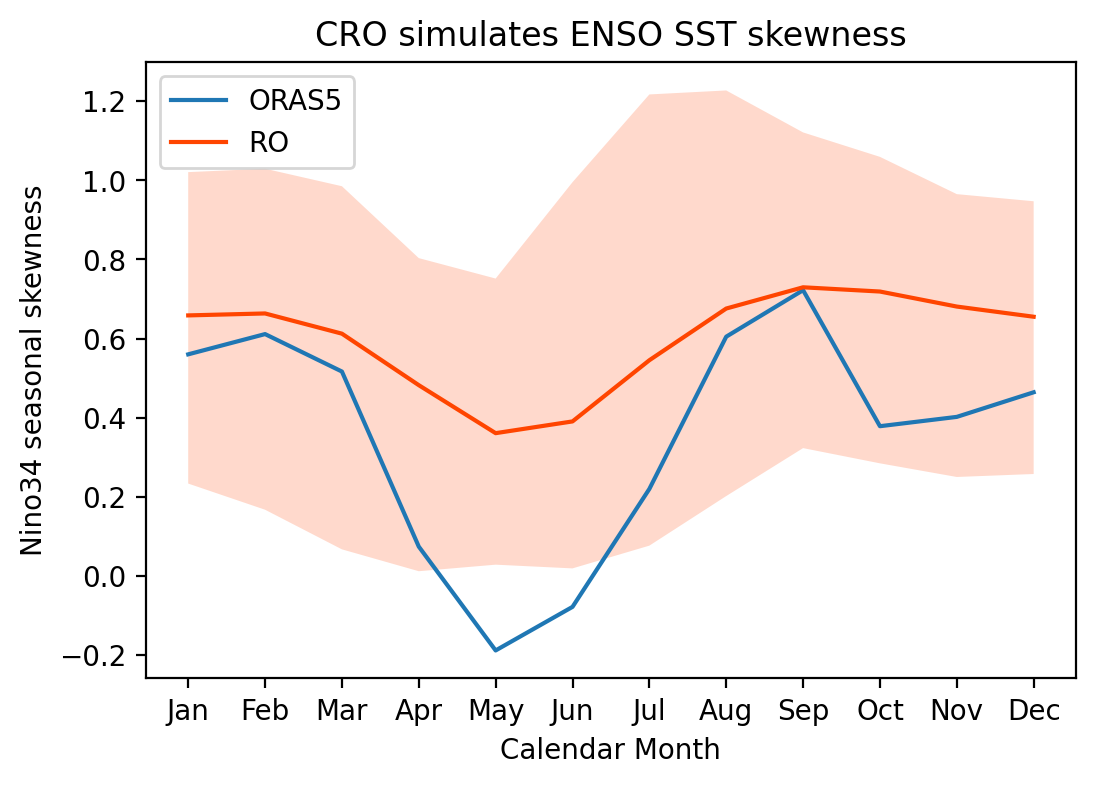

In [6]:

obs_seaSK = obs_ds.groupby('time.month').skew('time')
RO_seaSK = RO_sim.groupby('time.month').skew('time')

sel_var = "Nino34"
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
obs_seaSK[sel_var].plot(ax=ax, label='ORAS5')
XRO.plot_fill_between(RO_seaSK[sel_var], xtime=RO_seaSK.month, ax=ax, label='RO', option=0)

plt.legend()
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Nino34 seasonal skewness')
plt.xlabel('Calendar Month')
plt.title('CRO simulates ENSO SST skewness')



## Autocorrelation / Cross correlation

Autocorrelation measures the persistence of Niño3.4 SST anomalies, while cross-correlation between Niño3.4 and WWV reveals the recharge-discharge cycle that underlies ENSO dynamics.

A realistic Recharge Oscillator should reproduce

- the observed persistence of SST anomalies,
- WWV leading SST during event growth, and
- SST leading WWV during the discharge phase.


In [7]:
obs_ccr = XRO.xcorr(obs_ds, obs_ds['Nino34'], maxlags=36)
RO_ccr = XRO.xcorr(RO_sim, RO_sim['Nino34'], maxlags=36)

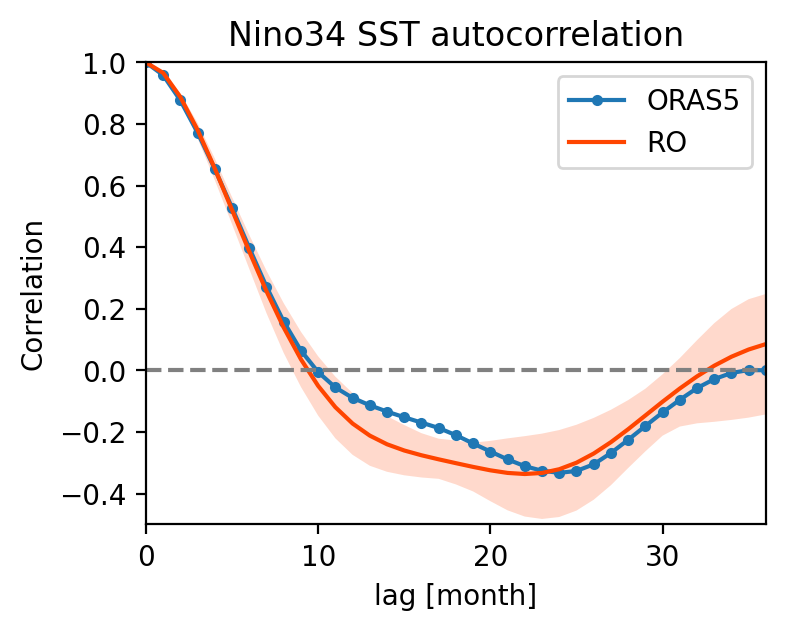

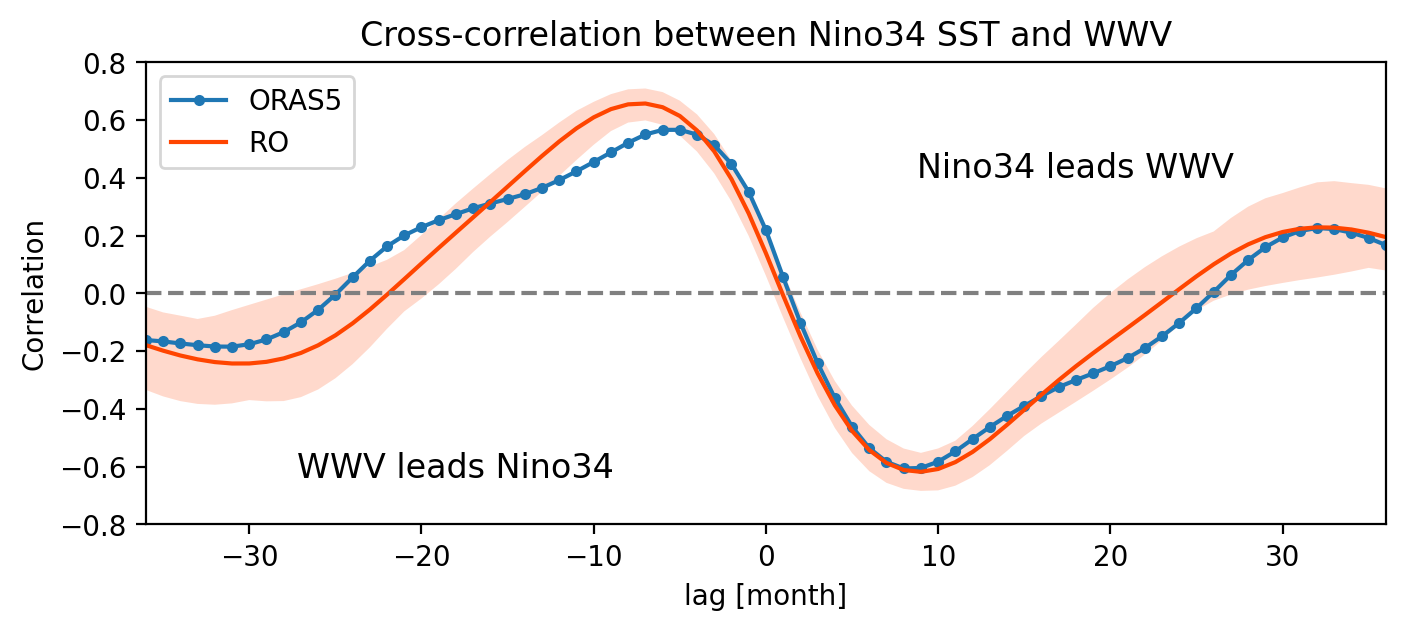

In [8]:
sel_var = "Nino34"

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
obs_ccr[sel_var].plot(ax=ax, marker='.', label='ORAS5')
XRO.plot_fill_between(RO_ccr[sel_var], xtime=RO_ccr.lag, ax=ax, label='RO', option=0)
ax.set_xlim([0, 36])
ax.axhline(0, ls='--', c='gray')
ax.set_ylim([-0.5, 1])
ax.set_ylabel("Correlation")
ax.set_title("Nino34 SST autocorrelation")
ax.legend()

sel_var = "WWV"

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
obs_ccr[sel_var].plot(ax=ax, marker='.', label='ORAS5')
XRO.plot_fill_between(RO_ccr[sel_var], xtime=RO_ccr.lag, ax=ax, label='RO', option=0)
ax.set_xlim([-36, 36])
ax.axhline(0, ls='--', c='gray')
ax.text(0.25, 0.1,'WWV leads Nino34', ha='center', transform=ax.transAxes, fontsize='large')
ax.text(0.75, 0.75,'Nino34 leads WWV', ha='center', transform=ax.transAxes, fontsize='large')
ax.set_ylim([-0.8, 0.8])
ax.set_ylabel("Correlation")
ax.set_title("Cross-correlation between Nino34 SST and WWV")
ax.legend()

## ENSO spectrum analysis

Finally, we examine the frequency characteristics of the simulated ENSO variability using Thomson's multitaper spectral estimator (See `pmtm` in XRO `stats.py`).

The observed ENSO spectrum is characterized by

- a dominant peak near **2.5–5.5 years (`fE`)**, corresponding to the intrinsic ENSO oscillation, and
- weaker combination modes (`1-fE` and `1+fE`) produced by interactions between the annual cycle and ENSO.

Comparing the simulated and observed spectra provides a stringent test of whether the fitted stochastic model reproduces the dominant timescales of ENSO variability.

Reference: Stuecker, M. F., Timmermann, A., Jin, F.-F., McGregor, S., & Ren, H.-L. (2013). A combination mode of the annual cycle and the El Niño/Southern Oscillation. Nature Geoscience, 6(7), 540–544. https://doi.org/10.1038/ngeo1826

In [9]:
psd_obs, psd_sig_obs, psd_ci_obs = XRO.pmtm( obs_ds['Nino34'], dim='time', dt=1/12, nw=5, lag1_r=None)
psd_RO, psd_sig_RO, psd_ci_RO = XRO.pmtm( RO_sim['Nino34'], dim='time', dt=1/12, nw=5, lag1_r=None)

Text(0.5, 1.0, 'Spectrum of Niño3.4 SST anomaly')

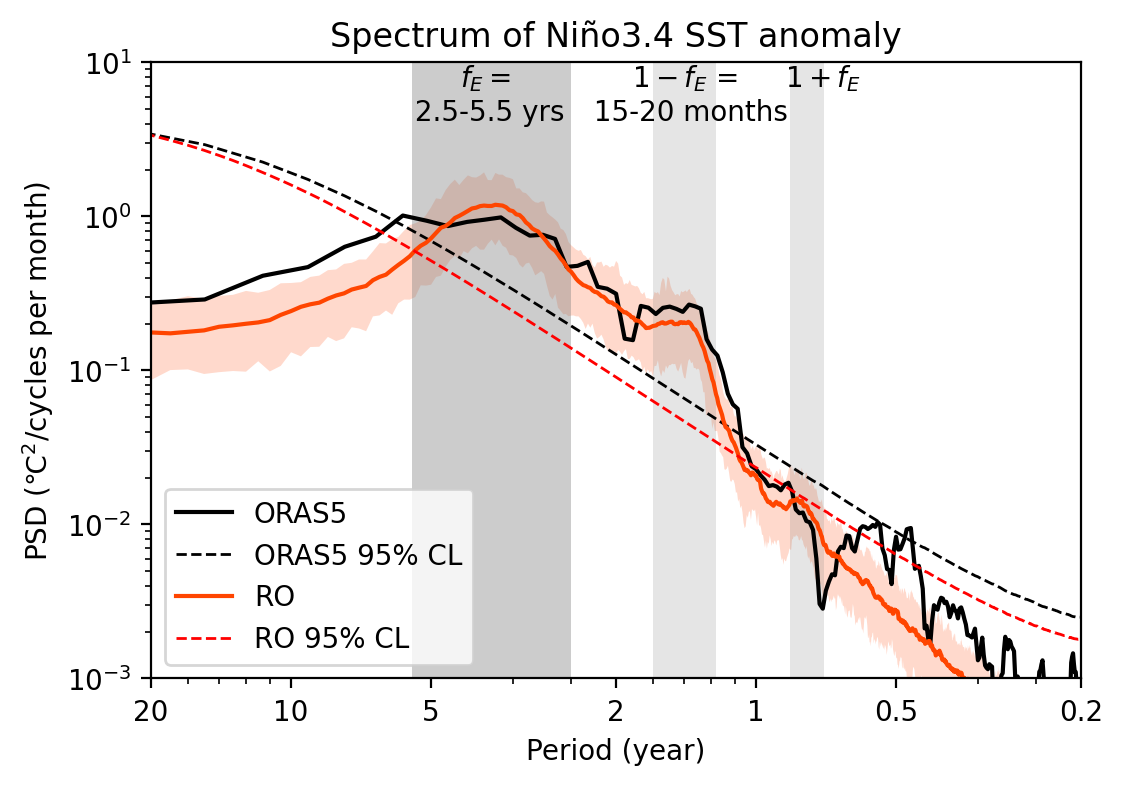

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.loglog(psd_obs.freq, psd_obs, lw=1.5, color='k', label='ORAS5')
ax.plot(psd_sig_obs.freq, psd_sig_obs, lw=1., color='k', linestyle='--', label='ORAS5 95% CL')

XRO.plot_fill_between(psd_RO, xtime=psd_RO.freq, ax=ax, label='RO', option=0.05)
ax.plot(psd_sig_RO.freq, psd_sig_RO.median('member'), lw=1., color='red', linestyle='--', label='RO 95% CL')

per = [50,20,10,5,2,1,0.5,0.2]
xt = 1.0/np.array(per)
ax.set_xticks(xt)
ax.set_xticklabels(map(str, per))
ax.set_ylabel('PSD (℃$^2$/cycles per month)')
ax.set_xlabel('Period (year)')
ax.set_xlim([1/20, 5])
ax.set_ylim([1e-3, 10])

ax.legend(loc='lower left')

y_min, y_max = ax.get_ylim()
Mfreq_enso = np.array([1/2.5, 1/5.5])
Mfreq_fplus = 1 + Mfreq_enso
Mfreq_fmins = 1 - Mfreq_enso

ax.fill_between(Mfreq_enso, y_min, y_max, fc='gray', alpha=0.4)
ax.fill_between(Mfreq_fplus, y_min, y_max, fc='gray',  alpha=0.2)
ax.fill_between(Mfreq_fmins, y_min, y_max, fc='gray', alpha=0.2)

ax.text(np.mean(Mfreq_enso)*0.9, y_max, '$f_{E}=$\n 2.5-5.5 yrs', ha='center', va='top')
ax.text(np.mean(Mfreq_fplus)+0.1, y_max, '$1+f_{E}$', ha='center', va='top')

ax.text(np.mean(Mfreq_fmins), y_max, '$1-f_{E}$ = \n 15-20 months', ha='center', va='top')
ax.set_title('Spectrum of Niño3.4 SST anomaly')

## Summary

In this tutorial we

- fitted the Recharge Oscillator to observed Niño3.4 and WWV,
- generated long stochastic ensemble simulations,
- reproduced the observed seasonal synchronization of ENSO,
- captured the nonlinear asymmetry between El Niño and La Niña,
- recovered the observed recharge-discharge relationship between SST and WWV, and
- reproduced the dominant spectral characteristics of ENSO.

This example demonstrates that the stochastic Recharge Oscillator provides a compact yet physically interpretable framework for understanding and simulating the essential dynamics of ENSO.

Beyond reproducing observations, **pyCRO** provides a powerful framework for numerical experiments. By systematically perturbing individual RO parameters—such as the ocean-atmosphere coupling strength, damping, nonlinear feedbacks, or stochastic forcing—you can directly investigate how each physical process influences ENSO amplitude, periodicity, predictability, seasonal phase locking, and nonlinear asymmetry. Such parameter perturbation experiments offer an intuitive and computationally efficient way to understand the mechanisms controlling ENSO dynamics and to test hypotheses about climate variability.
